# VisuoShell Force Estimation

This notebook mirrors the VisuoShell workflow inside `dismech-python`: load tracked 3D marker CSVs, build a shell mesh from the reference frame, estimate nodal balance forces, and visualize the force field over time.

In [1]:
from pathlib import Path

import numpy as np

from dismech.visuoshell import (
    VisuoShellForceEstimator,
    VisuoShellVisualizationOptions,
    get_force_animation_plotly,
    get_force_figure,
    load_nodes,
)

## Settings

Set `DATA_DIR` to a folder containing tracked 3D CSV frames. Each CSV should have the same format as VisuoShell's `tracked_3d.csv` style data, where columns 1, 2, and 3 are x, y, z positions.

In [ ]:
# Example options:
# DATA_DIR = Path("/Users/radha/GitRepos/VisuoShell/dot_detection_pipline/example_dot_10mm")
DATA_DIR = Path("/Users/radha/GitRepos/VisuoShell/test_data")

OUTPUT_FORCES = Path("forces_midedge.txt")
OUTPUT_HTML = Path("visuoshell_forces_midedge.html")

KB = 1.0e9
MESH_METHOD = "convex_hull"  # "convex_hull" or "delaunay"
PLOT_STEP = 1
ARROW_SCALE = 1.0

## Load Tracked Frames

In [3]:
nodes_by_frame = load_nodes(DATA_DIR)

if not nodes_by_frame:
    raise ValueError(f"No usable CSV frames found in {DATA_DIR}")

frame_names = sorted(nodes_by_frame)
reference_nodes = nodes_by_frame[frame_names[0]]

print(f"Loaded {len(nodes_by_frame)} frame(s)")
print(f"Reference frame: {frame_names[0]}")
print(f"Nodes per frame: {reference_nodes.shape[0]}")

Loaded 5 frame(s)
Reference frame: ref.csv
Nodes per frame: 49


## Build Mesh and Force Estimator

The first valid frame is treated as the natural/rest shape, equivalent to VisuoShell's reference-frame mesh construction.

In [4]:
estimator = VisuoShellForceEstimator.from_reference_points(
    reference_nodes,
    kb=KB,
    mesh_method=MESH_METHOD,
    use_midedge=True
)

print(f"Triangles: {estimator.triangles.shape[0]}")
print(f"Hinges: {estimator.mesh.hinge_nodes.shape[0]}")
print(f"Boundary edges: {len(estimator.mesh.boundary_edges)}")

Triangles: 81
Hinges: 114
Boundary edges: 15


## Estimate Balance Forces

`external_balance_force` returns the external nodal force that would balance the elastic hinge force. This is the same sign convention as VisuoShell's `accumulate_forces` output.

In [5]:
forces_by_frame = {
    frame_name: estimator.external_balance_force(nodes)
    for frame_name, nodes in nodes_by_frame.items()
}

with OUTPUT_FORCES.open("w") as f:
    for frame_name in frame_names:
        f.write(f"{frame_name}\n")
        np.savetxt(f, forces_by_frame[frame_name], delimiter=",")
        f.write("\n")

max_force = max(np.linalg.norm(force, axis=1).max() for force in forces_by_frame.values())
print(f"Wrote forces to {OUTPUT_FORCES.resolve()}")
print(f"Max nodal force magnitude: {max_force:.6e}")

Wrote forces to /Users/radha/GitRepos/dismech-python/examples/forces.txt
Max nodal force magnitude: 3.431459e+14


## Single-Frame Visualization

In [6]:
options = VisuoShellVisualizationOptions(
    title="VisuoShell Force Estimation",
    plot_step=PLOT_STEP,
    arrow_scale=ARROW_SCALE,
)

frame_name = frame_names[0]
fig_single = get_force_figure(
    nodes_by_frame[frame_name],
    forces_by_frame[frame_name],
    estimator.triangles,
    title=f"Reference frame: {frame_name}",
    options=options,
)
fig_single.show()

## Animated Visualization

This is the closest notebook analogue to VisuoShell's PyVista loop: the shell is colored by force magnitude, marker points are shown, edges are drawn, and cones show force direction.

In [10]:
fig_anim = get_force_animation_plotly(
    nodes_by_frame,
    forces_by_frame,
    estimator.triangles,
    options=options,
)
fig_anim.show()

## Save Interactive HTML

In [8]:
fig_anim.write_html(OUTPUT_HTML)
print(f"Wrote animation to {OUTPUT_HTML.resolve()}")

Wrote animation to /Users/radha/GitRepos/dismech-python/examples/visuoshell_forces.html


/Users/radha/GitRepos/dismech-python/.venv/lib/python3.13/site-packages/dismech/visuoshell/visualization.py:300: UserWarning:

Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"



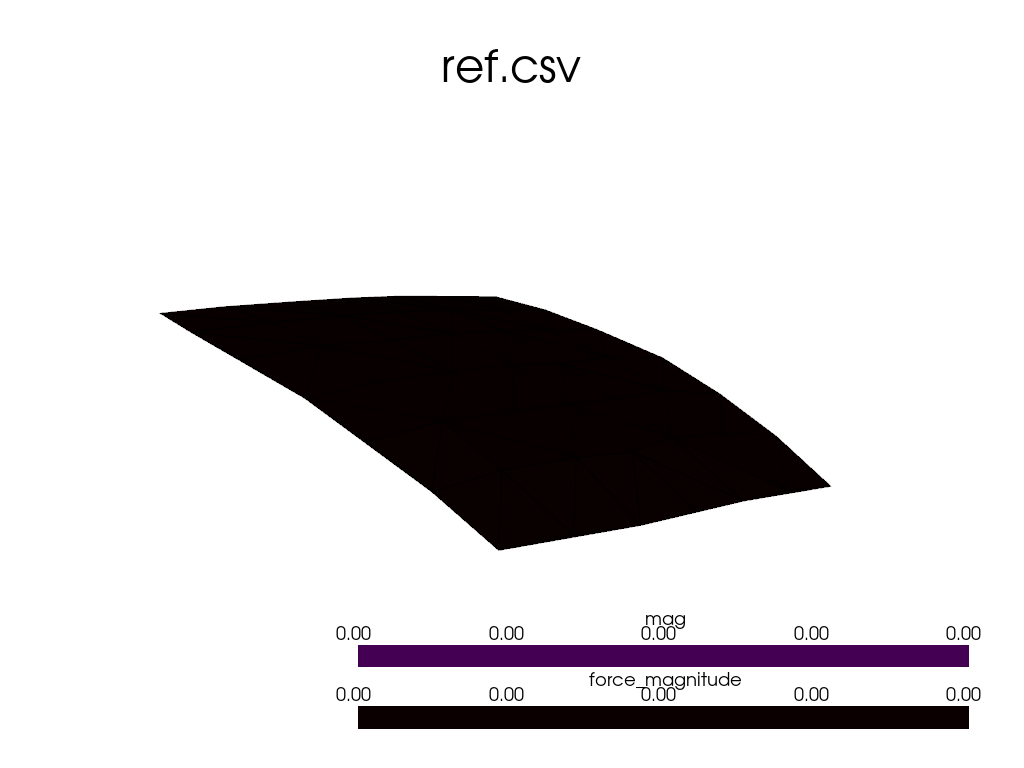

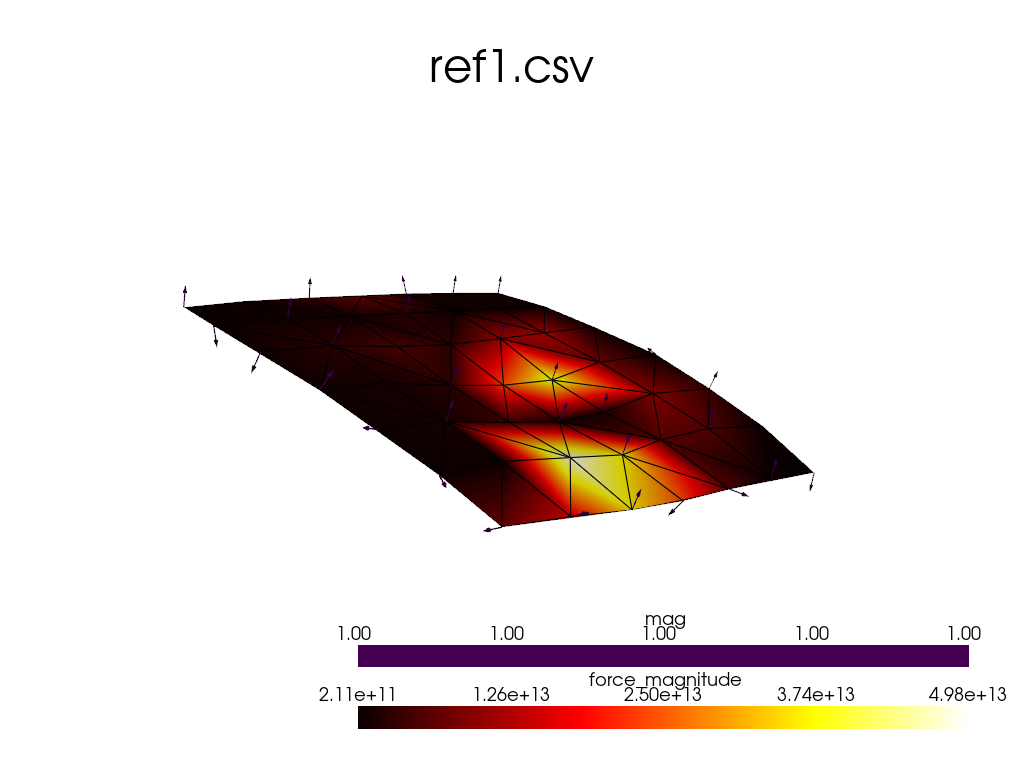

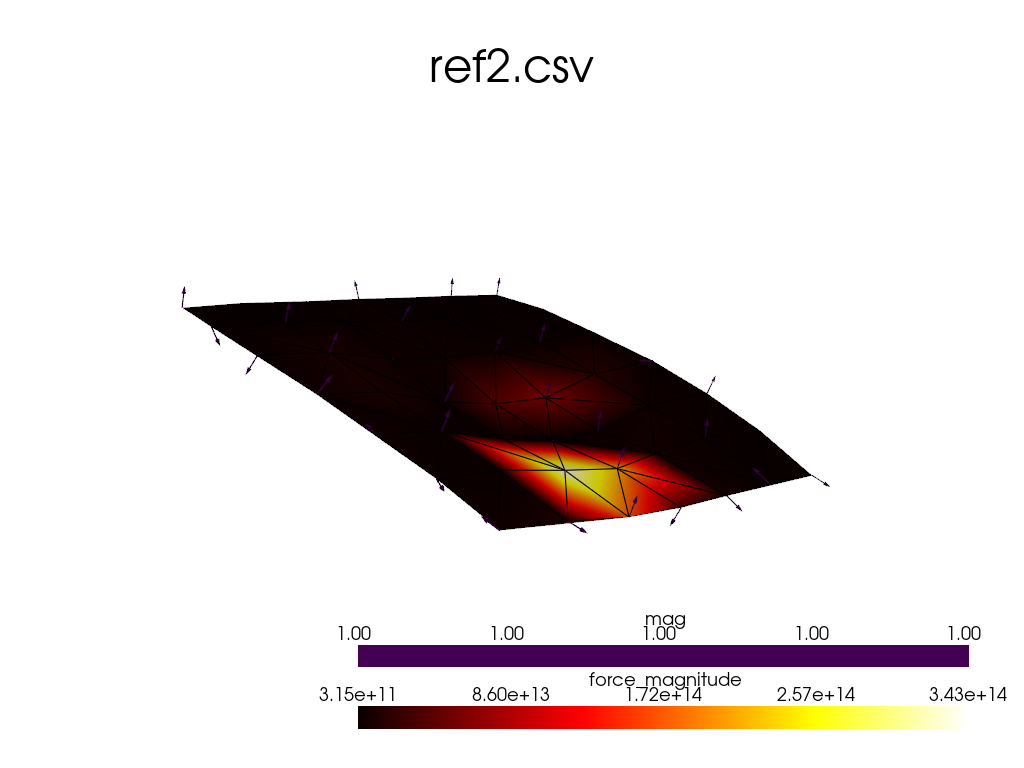

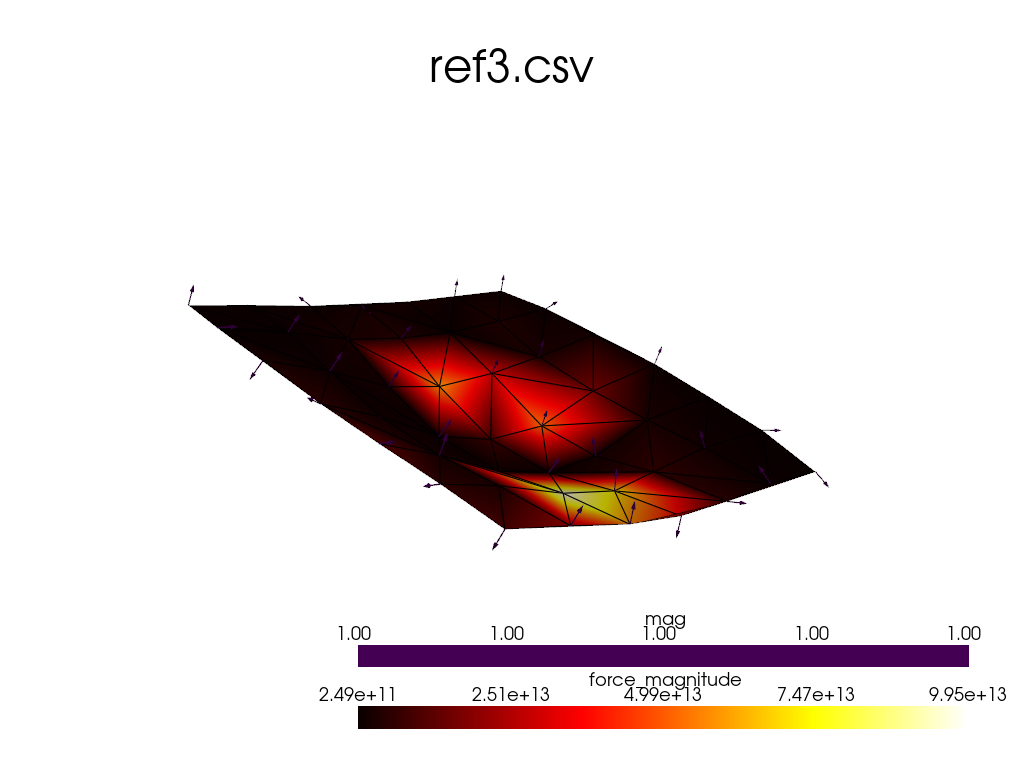

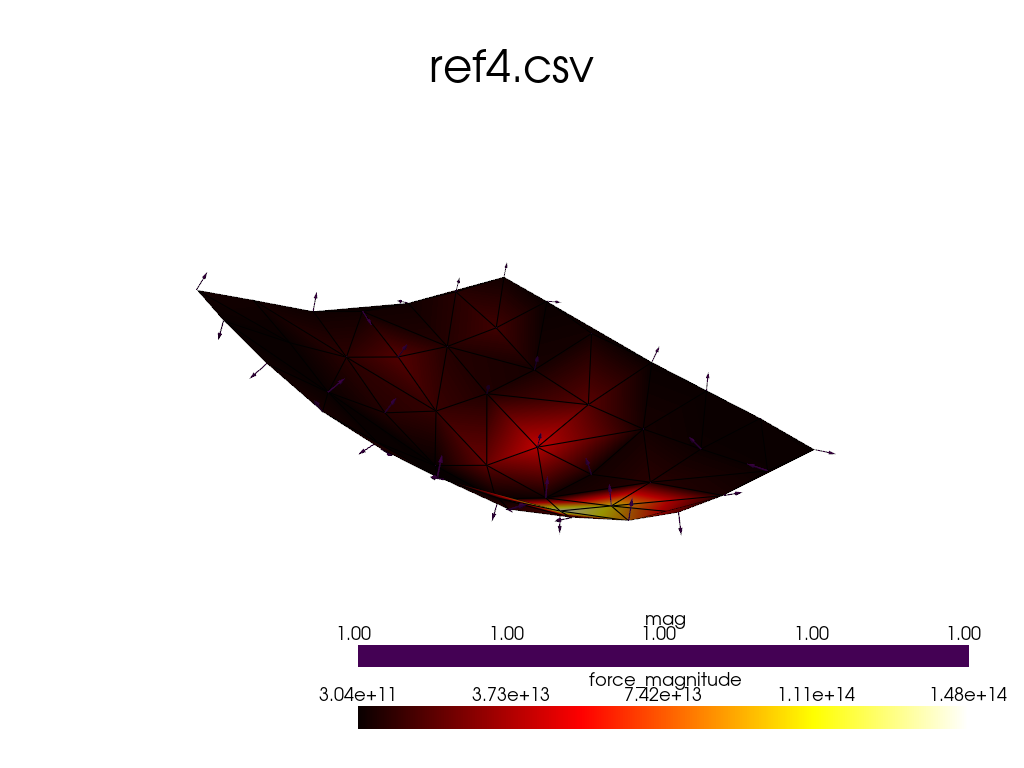

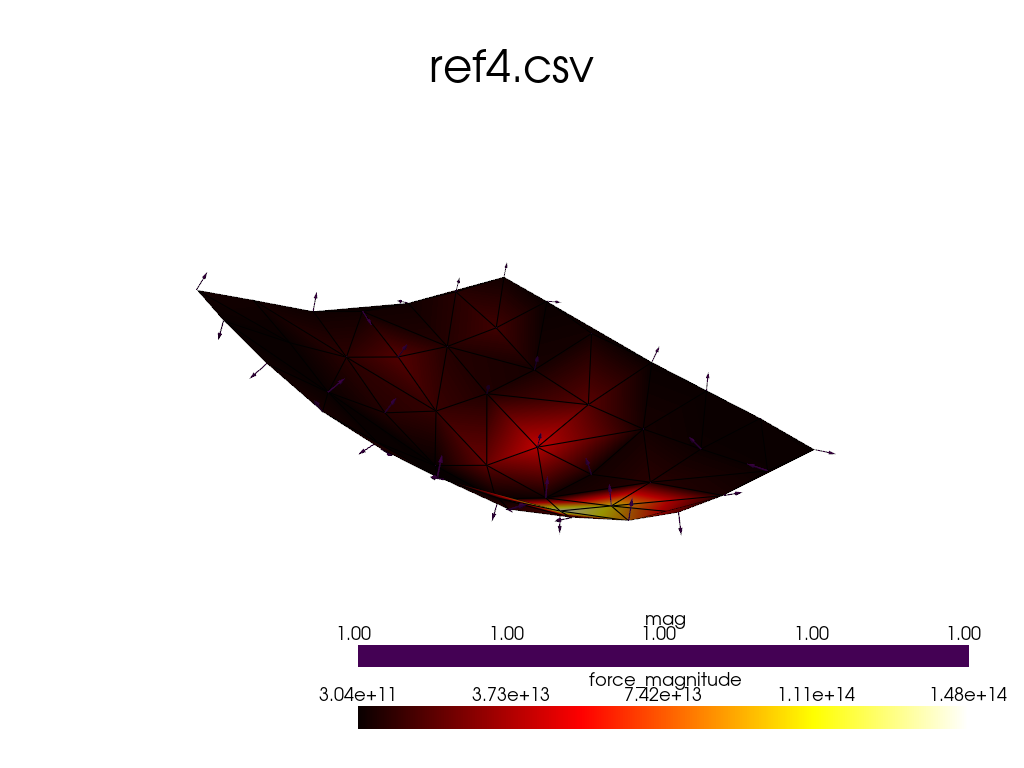

In [9]:
from dismech.visuoshell import visualize_pyvista

visualize_pyvista(
    nodes_by_frame,
    forces_by_frame,
    estimator.triangles,
    options=options,
)
